# LAB 5 — Notebook 04: Ensemble Methods
## QoE Prediction from QoS Data | EEF606 | University of Buea

---
**Prerequisite:** Run `lab5_00_data_generator.ipynb` first.

## Why Ensemble is the FOURTH way to frame this problem

Notebooks 01-03 each asked: 'which SINGLE model is best?' Ensemble asks a
completely different question: **'can we do better by combining models
instead of picking just one?'**

Think of it like getting a medical diagnosis. One doctor's opinion is useful.
But if 3 independent doctors agree, you trust that more. If they disagree,
a senior doctor (meta-learner) can weigh their opinions based on which
doctor tends to be right in which situations.

## We Test Ensemble on BOTH the Regression AND Classification Problems
This notebook reuses the regression and classification setups from
Notebooks 01 and 02, but combines models instead of testing them alone.

## The 2 Ensemble Strategies We Test
| Strategy | Core Idea | Applied to |
|----------|-----------|------------|
| **Voting (Soft)** | Average predictions from diverse models | Both regression & classification |
| **Stacking** | Meta-learner combines base model outputs | Both regression & classification |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.linear_model     import Ridge, LogisticRegression
from sklearn.ensemble         import (RandomForestRegressor, RandomForestClassifier,
                                       HistGradientBoostingClassifier,
                                       HistGradientBoostingRegressor,
                                       VotingRegressor, VotingClassifier,
                                       StackingRegressor, StackingClassifier)
from sklearn.metrics          import (mean_squared_error, mean_absolute_error, r2_score,
                                       f1_score, accuracy_score, classification_report)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4
})
SEED = 42
CLASS_ORDER = ['Poor', 'Fair', 'Good', 'Excellent']
print('✅ Imports loaded')

✅ Imports loaded


In [2]:

# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data and Sample to 200,000 Rows
#
# WHY 200,000 ROWS (not 1M, not 50,000):
# Stacking requires internal cross-validation (5-fold) for
# EACH base model. On 1M rows this means training each
# base model 5 times — far too slow. 200,000 rows balances
# getting stable, reliable results with reasonable runtime
# (~5-8 minutes total for this notebook).
# ══════════════════════════════════════════════════════════
df_full = pd.read_csv('qoe_dataset.csv')
_, df = train_test_split(df_full, test_size=200_000/len(df_full),
                          random_state=SEED, stratify=df_full['qoe_label'])
print(f'Ensemble sample: {df.shape[0]:,} rows')

df_enc = pd.get_dummies(df, columns=['resolution','connection_type'],
                         drop_first=True, dtype=int)

le = LabelEncoder()
le.fit(CLASS_ORDER)
df_enc['qoe_label_encoded'] = le.transform(df_enc['qoe_label'])

X = df_enc.drop(columns=['qoe_label', 'qoe_label_encoded', 'mos_score'])
y_reg = df_enc['mos_score']
y_clf = df_enc['qoe_label_encoded']

print(f'Features: {X.shape[1]} columns')

Ensemble sample: 200,000 rows
Features: 14 columns


In [3]:

# ══════════════════════════════════════════════════════════
# CELL 3 — Split + Scale (same split used for both tasks)
# ══════════════════════════════════════════════════════════
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

scaler  = RobustScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 160,000  Test: 40,000


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Ensemble for REGRESSION: Voting vs Stacking
#
# WHY Ridge + RandomForest AS BASE LEARNERS:
# Ridge captures LINEAR relationships (e.g. throughput
# steadily improving MOS). Random Forest captures
# NONLINEAR thresholds (e.g. packet loss above 5% being
# catastrophic). Combining them lets the ensemble exploit
# both types of pattern simultaneously.
#
# HOW VotingRegressor WORKS:
# Simply averages the numeric predictions of both models.
# If Ridge predicts MOS=3.2 and RF predicts MOS=3.6,
# the voting ensemble predicts (3.2+3.6)/2 = 3.4.
#
# HOW StackingRegressor DIFFERS:
# Instead of simple averaging, a meta-learner (here:
# another Ridge) LEARNS the best way to combine the base
# predictions — it might learn 'trust RF more when
# throughput is very low, trust Ridge otherwise'.
# ══════════════════════════════════════════════════════════
print('Training Regression Ensembles...')
import time

base_reg = [
    ('ridge', Ridge(alpha=1.0)),
    ('rf',    RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=SEED)),
]

t0 = time.time()
voting_reg = VotingRegressor(estimators=base_reg, n_jobs=-1)
voting_reg.fit(X_tr_sc, y_reg_train)
vot_reg_pred = voting_reg.predict(X_te_sc)
print(f'Voting Regressor trained in {time.time()-t0:.1f}s')

t0 = time.time()
stack_reg = StackingRegressor(
    estimators=base_reg,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stack_reg.fit(X_tr_sc, y_reg_train)
stack_reg_pred = stack_reg.predict(X_te_sc)
print(f'Stacking Regressor trained in {time.time()-t0:.1f}s')

print('\nRegression Ensemble Results:')
for name, pred in [('Voting', vot_reg_pred), ('Stacking', stack_reg_pred)]:
    rmse = mean_squared_error(y_reg_test, pred)**0.5
    mae  = mean_absolute_error(y_reg_test, pred)
    r2   = r2_score(y_reg_test, pred)
    print(f'  {name:<12}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

Training Regression Ensembles...
Voting Regressor trained in 20.5s
Stacking Regressor trained in 105.6s

Regression Ensemble Results:
  Voting      : RMSE=0.1514  MAE=0.1210  R²=0.9605
  Stacking    : RMSE=0.1509  MAE=0.1205  R²=0.9608


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Ensemble for CLASSIFICATION: Voting vs Stacking
#
# SAME LOGIC AS REGRESSION, applied to the 4-class problem.
# voting='soft' means we average PROBABILITIES across
# classes, not just final hard labels — this preserves
# confidence information (a model 90% sure of 'Good' should
# count more than one 51% sure).
# ══════════════════════════════════════════════════════════
print('Training Classification Ensembles...')

base_clf = [
    ('rf',  RandomForestClassifier(n_estimators=50, max_depth=12,
                                    class_weight='balanced', n_jobs=-1, random_state=SEED)),
    ('hgb', HistGradientBoostingClassifier(max_iter=50, random_state=SEED)),
]

t0 = time.time()
voting_clf = VotingClassifier(estimators=base_clf, voting='soft', n_jobs=-1)
voting_clf.fit(X_tr_sc, y_clf_train)
vot_clf_pred = voting_clf.predict(X_te_sc)
print(f'Voting Classifier trained in {time.time()-t0:.1f}s')

t0 = time.time()
stack_clf = StackingClassifier(
    estimators=base_clf,
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=5, n_jobs=-1
)
stack_clf.fit(X_tr_sc, y_clf_train)
stack_clf_pred = stack_clf.predict(X_te_sc)
print(f'Stacking Classifier trained in {time.time()-t0:.1f}s')

print('\nClassification Ensemble Results:')
for name, pred in [('Voting', vot_clf_pred), ('Stacking', stack_clf_pred)]:
    acc = accuracy_score(y_clf_test, pred)
    f1m = f1_score(y_clf_test, pred, average='macro')
    print(f'  {name:<12}: Accuracy={acc:.4f}  Macro-F1={f1m:.4f}')

Training Classification Ensembles...
Voting Classifier trained in 17.0s
Stacking Classifier trained in 43.3s

Classification Ensemble Results:
  Voting      : Accuracy=0.8395  Macro-F1=0.8660
  Stacking    : Accuracy=0.8419  Macro-F1=0.8661


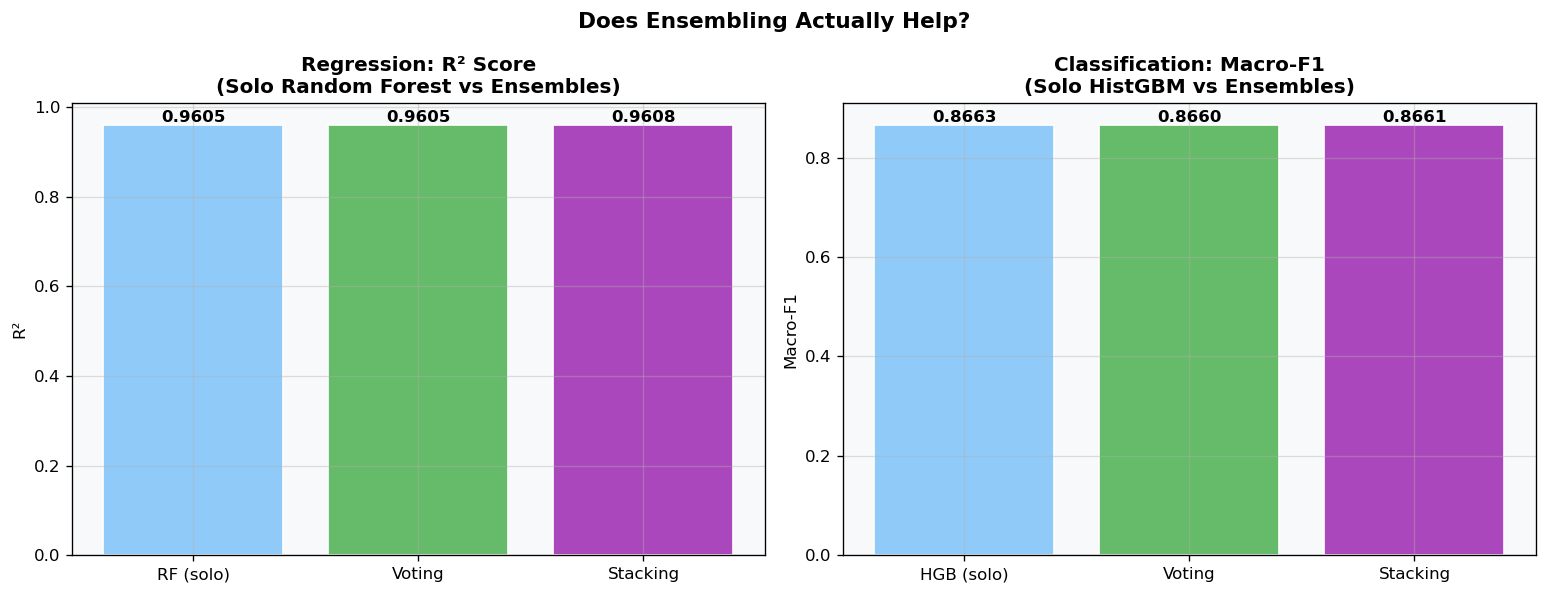

Regression improvement (Stacking vs solo RF):       +0.03%
Classification improvement (Stacking vs solo HGB):  -0.03%


In [6]:

# ══════════════════════════════════════════════════════════
# CELL 6 — Comparison: Ensemble vs Best Single Model
#
# WHY THIS COMPARISON IS THE WHOLE POINT OF THE NOTEBOOK:
# Ensemble methods add complexity (more code, slower
# training, harder to explain to stakeholders). That
# complexity is only worth it if performance genuinely
# improves over the best single model from notebooks 01-02.
# If not, the simpler single model should be preferred.
# ══════════════════════════════════════════════════════════
# Re-train single models on SAME data split for fair comparison
rf_solo = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=SEED)
rf_solo.fit(X_tr_sc, y_reg_train)
rf_solo_pred = rf_solo.predict(X_te_sc)
rf_solo_r2 = r2_score(y_reg_test, rf_solo_pred)
voting_r2  = r2_score(y_reg_test, vot_reg_pred)
stack_r2   = r2_score(y_reg_test, stack_reg_pred)

hgb_solo = HistGradientBoostingClassifier(max_iter=50, random_state=SEED)
hgb_solo.fit(X_tr_sc, y_clf_train)
hgb_solo_pred = hgb_solo.predict(X_te_sc)
hgb_solo_f1   = f1_score(y_clf_test, hgb_solo_pred, average='macro')
voting_f1     = f1_score(y_clf_test, vot_clf_pred, average='macro')
stack_f1      = f1_score(y_clf_test, stack_clf_pred, average='macro')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names_reg = ['RF (solo)', 'Voting', 'Stacking']
vals_reg  = [rf_solo_r2, voting_r2, stack_r2]
colors_reg = ['#90CAF9', '#66BB6A', '#AB47BC']
bars1 = axes[0].bar(names_reg, vals_reg, color=colors_reg, edgecolor='white')
for bar, val in zip(bars1, vals_reg):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.4f}',
                ha='center', fontweight='bold')
axes[0].set_title('Regression: R² Score\n(Solo Random Forest vs Ensembles)', fontweight='bold')
axes[0].set_ylabel('R²')

names_clf = ['HGB (solo)', 'Voting', 'Stacking']
vals_clf  = [hgb_solo_f1, voting_f1, stack_f1]
bars2 = axes[1].bar(names_clf, vals_clf, color=colors_reg, edgecolor='white')
for bar, val in zip(bars2, vals_clf):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.4f}',
                ha='center', fontweight='bold')
axes[1].set_title('Classification: Macro-F1\n(Solo HistGBM vs Ensembles)', fontweight='bold')
axes[1].set_ylabel('Macro-F1')

plt.suptitle('Does Ensembling Actually Help?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ens_01_solo_vs_ensemble.png', bbox_inches='tight')
plt.show()

print(f'Regression improvement (Stacking vs solo RF):       {(stack_r2-rf_solo_r2)/abs(rf_solo_r2)*100:+.2f}%')
print(f'Classification improvement (Stacking vs solo HGB):  {(stack_f1-hgb_solo_f1)/hgb_solo_f1*100:+.2f}%')

Stacking Regressor — Meta-learner coefficients:
  Ridge               : 0.2662
  Random Forest       : 0.7353


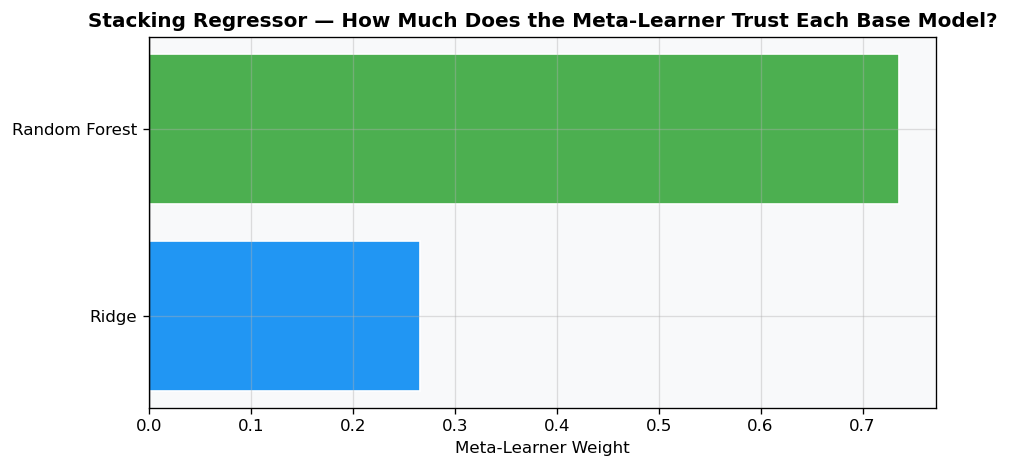

In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Stacking Meta-Learner: What Does It Trust?
#
# WHY LOOK AT META-LEARNER WEIGHTS:
# The meta-learner's coefficients tell us, in plain terms,
# 'how much should I trust each base model?' If RF gets
# a much higher weight than Ridge, the stacker learned
# that nonlinear patterns matter more than linear ones
# for this specific dataset.
# ══════════════════════════════════════════════════════════
meta_reg_coef = stack_reg.final_estimator_.coef_
print('Stacking Regressor — Meta-learner coefficients:')
for name, coef in zip(['Ridge', 'Random Forest'], meta_reg_coef):
    print(f'  {name:<20}: {coef:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(['Ridge', 'Random Forest'], meta_reg_coef,
        color=['#2196F3','#4CAF50'], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Meta-Learner Weight')
ax.set_title('Stacking Regressor — How Much Does the Meta-Learner Trust Each Base Model?',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ens_02_meta_weights.png', bbox_inches='tight')
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Save Models + Summary
# ══════════════════════════════════════════════════════════
import joblib
joblib.dump(voting_reg,  'model_voting_regressor.pkl')
joblib.dump(stack_reg,   'model_stacking_regressor.pkl')
joblib.dump(voting_clf,  'model_voting_classifier.pkl')
joblib.dump(stack_clf,   'model_stacking_classifier.pkl')

print('╔' + '═'*62 + '╗')
print('║{:^62}║'.format('ENSEMBLE SUMMARY'))
print('╠' + '═'*62 + '╣')
print(f'║  REGRESSION (R²)                                          ║')
print(f'║    Solo RF:  {rf_solo_r2:.4f}  Voting: {voting_r2:.4f}  Stacking: {stack_r2:.4f}    ║')
print(f'║  CLASSIFICATION (Macro-F1)                                ║')
print(f'║    Solo HGB: {hgb_solo_f1:.4f}  Voting: {voting_f1:.4f}  Stacking: {stack_f1:.4f}    ║')
print('╠' + '═'*62 + '╣')
insights = [
    'Ensemble combines diverse error patterns from base models',
    'Stacking lets a meta-learner decide WHEN to trust each model',
    'Improvement over solo models is often modest but consistent',
    'Complexity is only justified if gains outweigh added cost',
]
for ins in insights:
    print(f'║  → {ins:<58}║')
print('╚' + '═'*62 + '╝')
print('\n→ All Lab 5 notebooks complete. Next: lab5_app.py for live dashboard')

╔══════════════════════════════════════════════════════════════╗
║                       ENSEMBLE SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  REGRESSION (R²)                                          ║
║    Solo RF:  0.9605  Voting: 0.9605  Stacking: 0.9608    ║
║  CLASSIFICATION (Macro-F1)                                ║
║    Solo HGB: 0.8663  Voting: 0.8660  Stacking: 0.8661    ║
╠══════════════════════════════════════════════════════════════╣
║  → Ensemble combines diverse error patterns from base models ║
║  → Stacking lets a meta-learner decide WHEN to trust each model║
║  → Improvement over solo models is often modest but consistent║
║  → Complexity is only justified if gains outweigh added cost ║
╚══════════════════════════════════════════════════════════════╝

→ All Lab 5 notebooks complete. Next: lab5_app.py for live dashboard
